# Stock Time Series Clustering

This notebook walks through using `StockClusterer` to group stocks by the similarity of their price behavior over a given period.

We use 15 stocks across three sectors — tech, financials, and energy — and cluster them using KMeans with DTW distance, then inspect and visualize the results.

In [1]:
from clustering import StockClusterer

/Users/shivpalit/Desktop/shiv-github/ts-stock-clustering/.conda/lib/python3.11/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## Setup

Define the stock universe, normalization method, algorithm, and date range.

`change_method="Cumulative"` expresses each stock as its return relative to its starting price, making series comparable across different price levels while preserving trend shape.

In [2]:
stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "JPM", "BAC", "GS", "WFC", "C",
    "XOM", "CVX", "COP", "SLB", "MPC"
]

clusterer = StockClusterer(
    stocks=stocks,
    n_clusters=3,
    change_method="Cumulative",
    algo="KMeans",
    date_range=("2023-01-01", "2024-01-01"),
)

## Fit

Downloads price data from Yahoo Finance, applies the normalization, and runs the clustering algorithm.

In [3]:
clusterer.fit()

## Results

Print the cluster assignments and silhouette score. The silhouette score ranges from -1 to 1 — higher means clusters are more distinct and well-separated. Stocks that ended up alone in a cluster are excluded and listed under `unclustered`.

In [4]:
results = clusterer.get_results()
for cluster_id, tickers in results["clusters"].items():
    print(f"Cluster {cluster_id}: {tickers}")
print(f"\nSilhouette Score: {results['silhouette_score']:.4f}")
print(f"Unclustered: {results['unclustered']}")

Cluster 0: ['BAC', 'C', 'COP', 'CVX', 'GS', 'JPM', 'SLB', 'WFC', 'XOM']
Cluster 1: ['META']
Cluster 2: ['AAPL', 'AMZN', 'GOOGL', 'MPC', 'MSFT']

Silhouette Score: 0.7570
Unclustered: ['META']


## Visualization

Each subplot shows one cluster. Stock series are plotted at 50% opacity with the cluster center overlaid as a dashed black line — the center represents the average shape of that group.

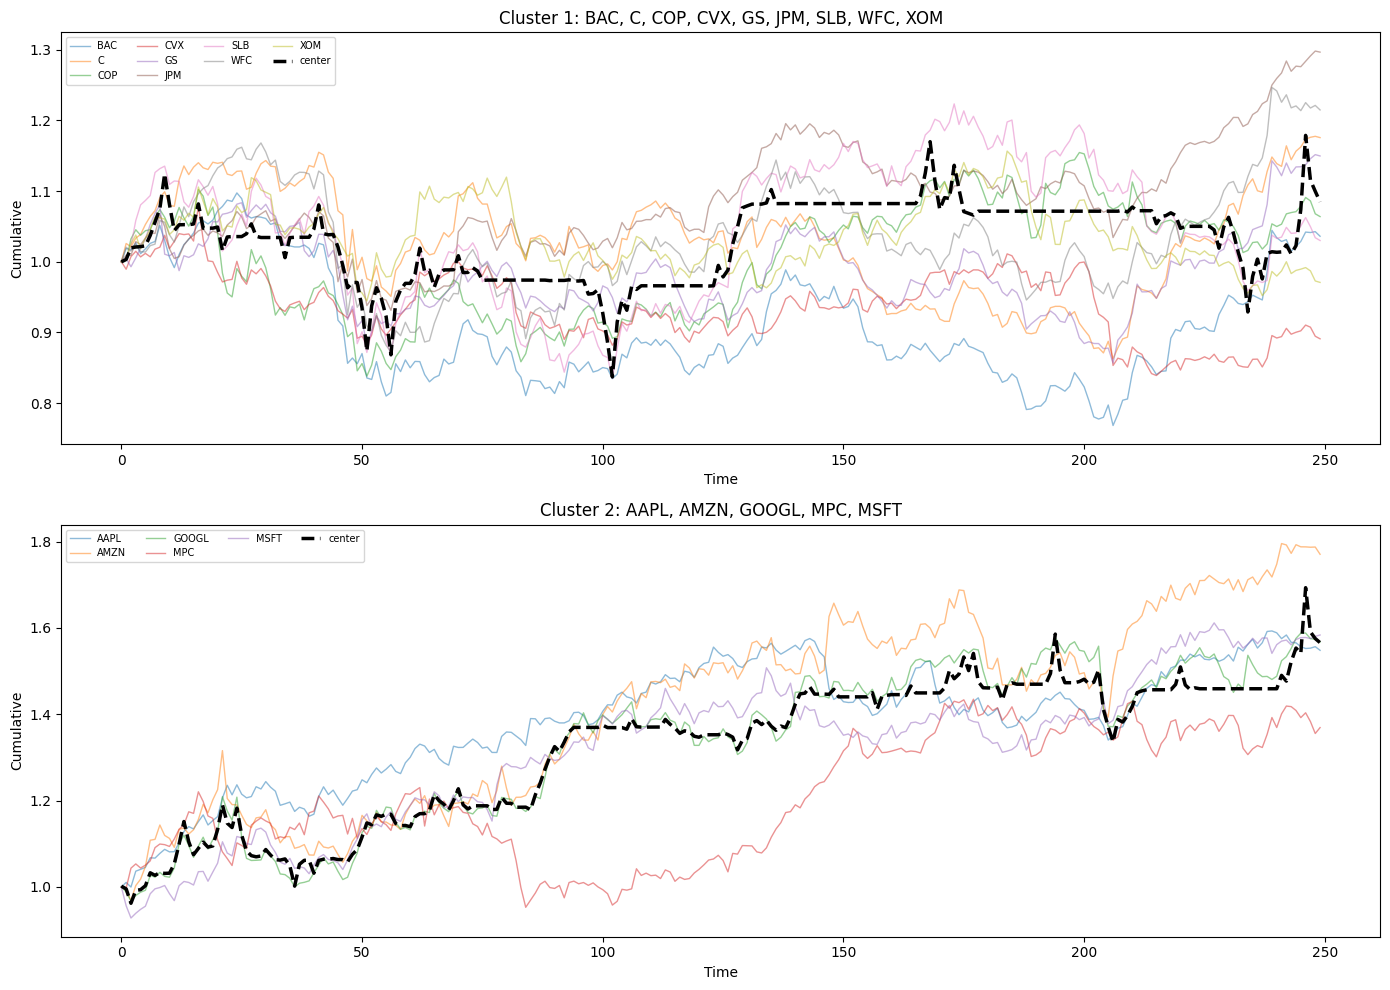

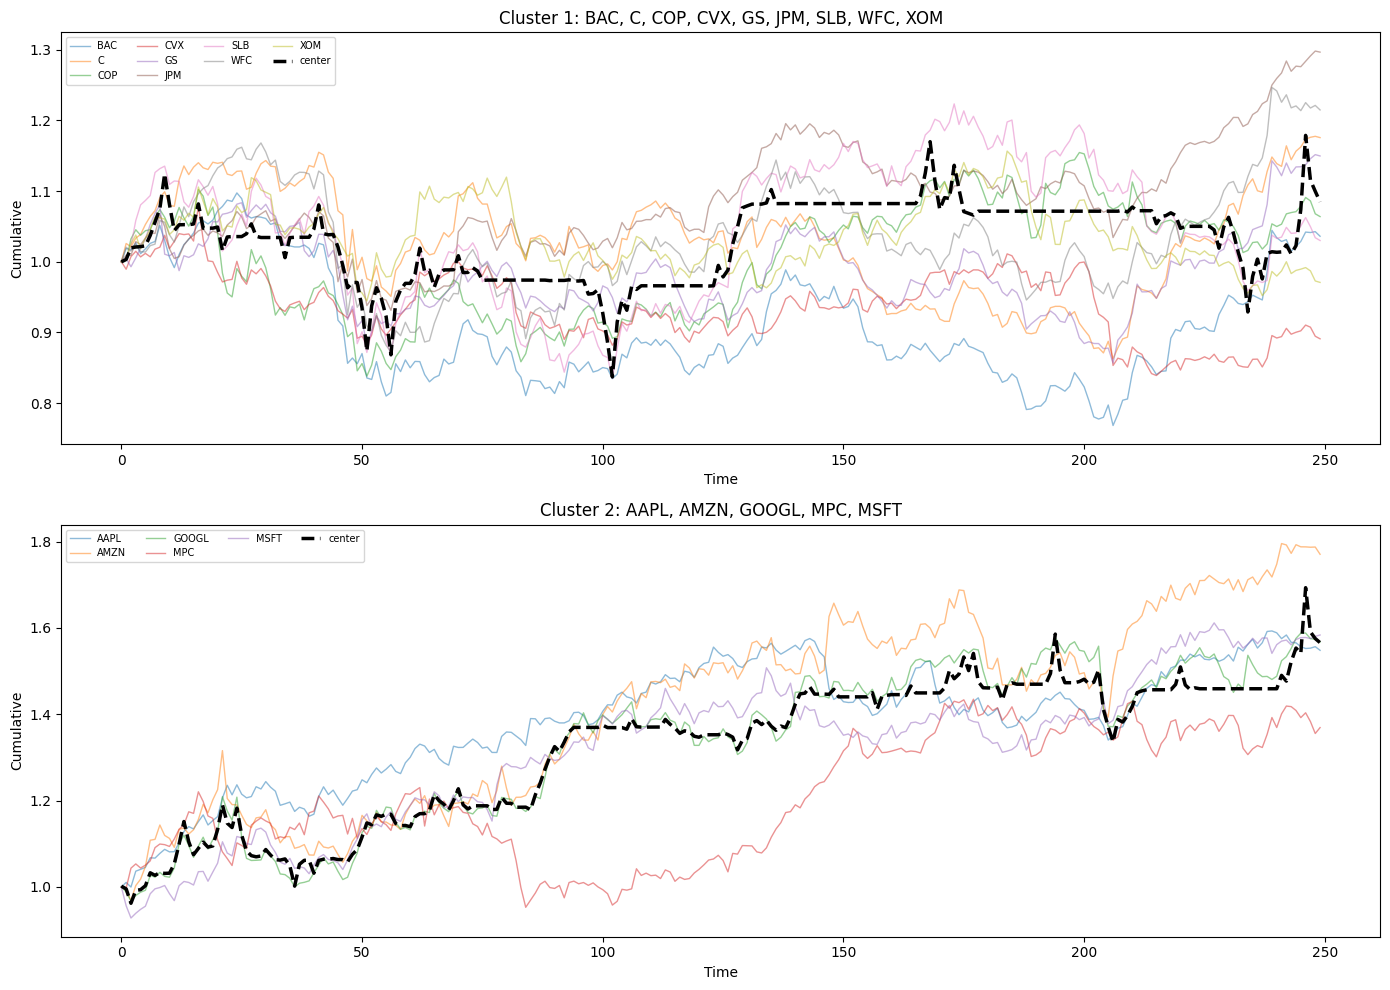

In [5]:
%matplotlib inline
clusterer.plot()